# Laboratorul 2
## Tema: Tehnici de învățare supervizată
Efectuat: Perebinos Daniel

### Instalarea dependentelor

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

### Preprocesarea datelor

In [2]:
import pandas as pd

df = pd.read_csv('titanic.csv', index_col=0)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [4]:
df.drop(columns=["Name", "Ticket", "Cabin", "Embarked"], inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 55.7+ KB


In [6]:
df["Sex"] = df["Sex"].apply(lambda x: 0 if x == "male" else 1)

In [7]:
df.fillna(0, inplace=True)

In [8]:
df.corr()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,0.543351,0.010539,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.131900,-0.361353,0.083081,0.018443,-0.549500
Sex,0.543351,-0.131900,1.000000,-0.024978,0.114631,0.245489,0.182333
Age,0.010539,-0.361353,-0.024978,1.000000,-0.184664,-0.048786,0.135516
SibSp,-0.035322,0.083081,0.114631,-0.184664,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,0.245489,-0.048786,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.182333,0.135516,0.159651,0.216225,1.000000


In [9]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,23.799293,0.523008,0.381594,32.204208
std,0.486592,0.836071,0.477990,17.596074,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,6.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,0.000000,24.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
from sklearn.model_selection import train_test_split

x = df[df.drop(columns=["Survived"]).columns].values
y = df["Survived"].values
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=16)

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

### Algoritmi bazati pe criteriul Bayes

Naive Bayes este un clasificator probabilistic bazat pe teorema lui Bayes, care presupune că trăsăturile de intrare sunt independente între ele, având un impact izolat asupra probabilității apariției unei clase. Modelul estimează probabilitatea fiecărei clase și face predicții pe baza celei mai mari probabilități.

In [12]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Precision: 0.7395833333333334
Recall: 0.6826923076923077
F1-Score: 0.71


<Axes: >

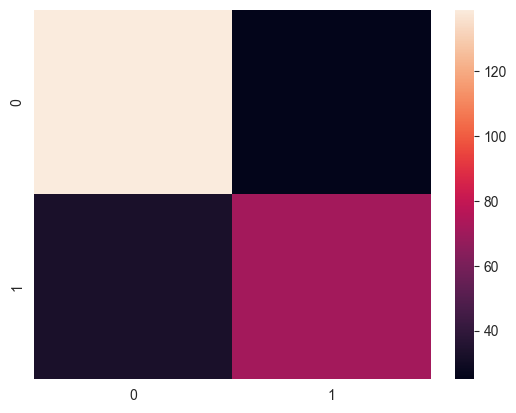

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred))

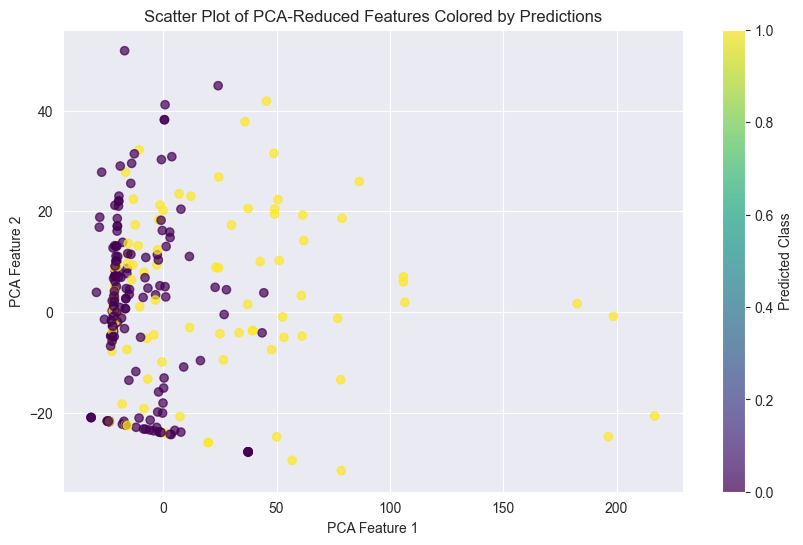

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='viridis', alpha=0.7)
plt.title("Scatter Plot of PCA-Reduced Features Colored by Predictions")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.colorbar(scatter, label="Predicted Class")
plt.show()

In [15]:
class_priors = model.class_prior_
class_means = model.theta_

print("GaussianNB Model Description:")
print(f"- Class Priors: {class_priors}")
print(f"- Class Means for Each Feature: {class_means}")

GaussianNB Model Description:
- Class Priors: [0.61797753 0.38202247]
- Class Means for Each Feature: [[ 2.54805195  0.15324675 23.75324675  0.49090909  0.32987013 22.18543091]
 [ 1.94537815  0.69327731 23.68978992  0.4789916   0.52521008 51.27225252]]


### Algoritmi bazati pe functii (SVM)

SVM este un algoritm de învățare supervisată care construiește un hiperplan de separare optim pentru a distinge diferitele clase de date, maximizând marginile dintre clase. Algoritmul poate utiliza kerneluri pentru a transforma datele într-un spațiu de dimensiuni mai mari pentru a le separa liniar, chiar și în cazurile în care datele nu sunt linear separabile.

In [16]:
from sklearn.svm import SVC

model = SVC(kernel='linear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Precision: 0.7555555555555555
Recall: 0.6538461538461539
F1-Score: 0.7010309278350515


<Axes: >

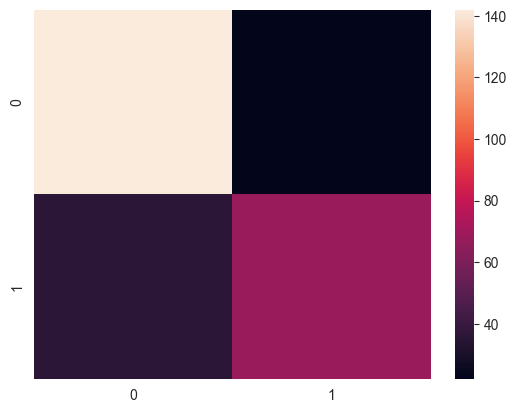

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred))

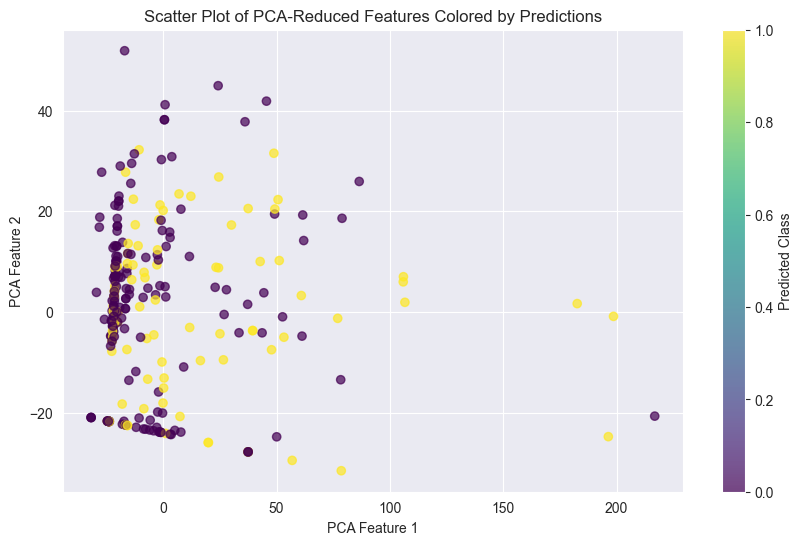

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='viridis', alpha=0.7)
plt.title("Scatter Plot of PCA-Reduced Features Colored by Predictions")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.colorbar(scatter, label="Predicted Class")
plt.show()

In [19]:
coef = model.coef_
intercept = model.intercept_
support_vectors = model.support_vectors_
n_support = model.n_support_

print("SVM Model Description:")
print(f"- Coefficients: {coef}")
print(f"- Intercept: {intercept}")
print(f"- Support Vectors: {support_vectors}")
print(f"- Number of support vectors for each class: {n_support}")

SVM Model Description:
- Coefficients: [[-1.49135580e-03  2.00074528e+00 -6.38649988e-05 -1.02942821e-03
  -5.25429354e-04  6.65435824e-05]]
- Intercept: [-0.99669159]
- Support Vectors: [[ 1.      0.     61.      0.      0.     33.5   ]
 [ 3.      0.      0.      0.      0.     14.5   ]
 [ 3.      1.     28.      1.      1.     14.4   ]
 ...
 [ 3.      1.     22.      0.      0.      7.25  ]
 [ 2.      1.     40.      1.      1.     39.    ]
 [ 1.      0.     27.      0.      0.     76.7292]]
- Number of support vectors for each class: [141 137]


### Algoritmi bazati pe arbori (Decision tree)

Arborele de decizie construiește un model ierarhic de decizii, unde fiecare nod reprezintă o trăsătură a datelor, iar ramurile reprezintă valorile posibile ale acestor trăsături. Acest proces continuă până când datele sunt complet clasificate, iar frunzele arborelui indică predicțiile finale.

In [20]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Precision: 0.7789473684210526
Recall: 0.7115384615384616
F1-Score: 0.7437185929648241


<Axes: >

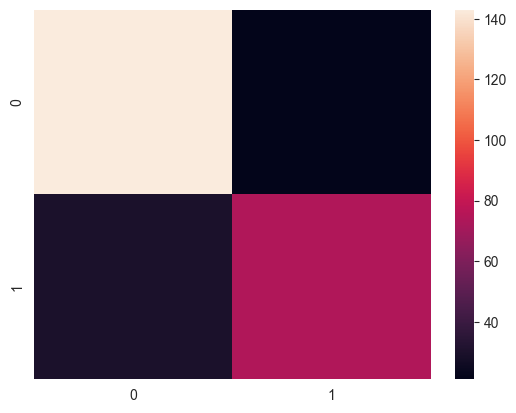

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred))

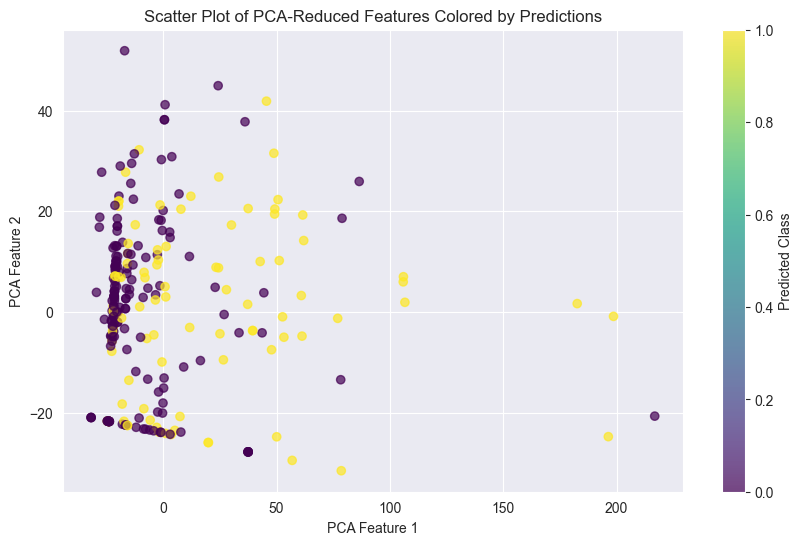

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='viridis', alpha=0.7)
plt.title("Scatter Plot of PCA-Reduced Features Colored by Predictions")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.colorbar(scatter, label="Predicted Class")
plt.show()

Feature Importances: [0.11130536 0.31422787 0.18500398 0.0767379  0.02821964 0.28450525]


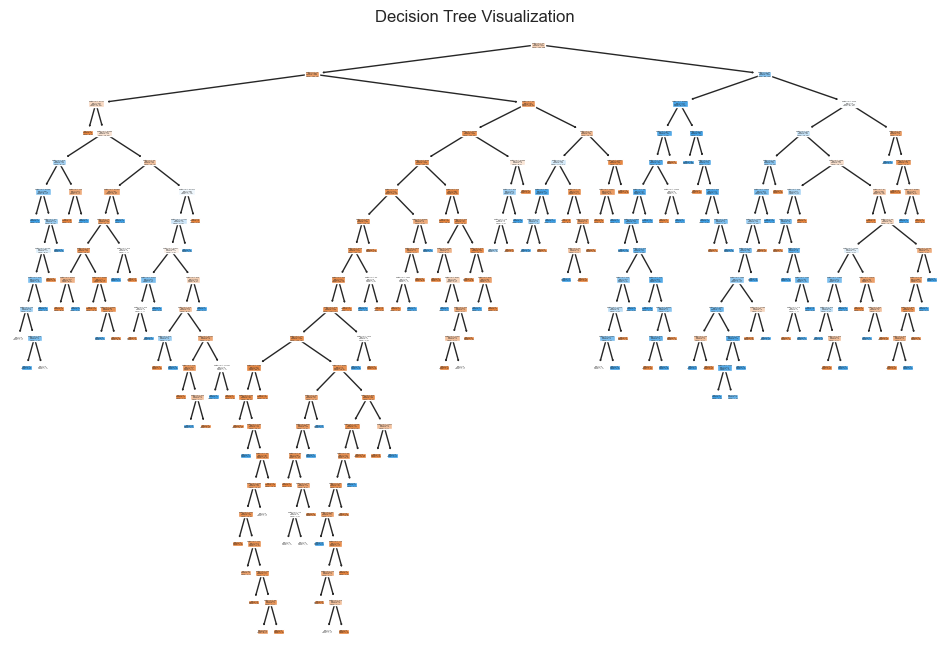

In [23]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

feature_importances = model.feature_importances_
print("Feature Importances:", feature_importances)
plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, feature_names=["Feature 1", "Feature 2", "Feature 3", "Feature 4", "Feature 5", "Feature 6"])
plt.title("Decision Tree Visualization")
plt.show()

### Algoritmi bazati pe meta metode (AdaBoost)

AdaBoost este o metodă de ensemble care combină mai mulți clasificatori slabi într-un singur clasificator puternic, punând accentul pe corectarea erorilor făcute de clasificatori anteriori. Fiecare model suplimentar este antrenat astfel încât să corecteze greșelile celor anteriori, iar predicțiile finale sunt obținute prin combinarea ponderată a tuturor clasificatorilor.

In [24]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Precision: 0.7169811320754716
Recall: 0.7307692307692307
F1-Score: 0.7238095238095238


<Axes: >

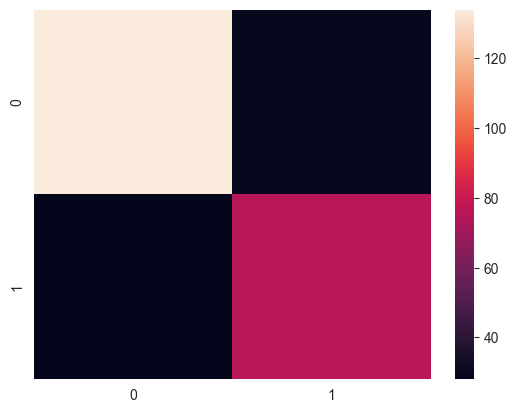

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred))

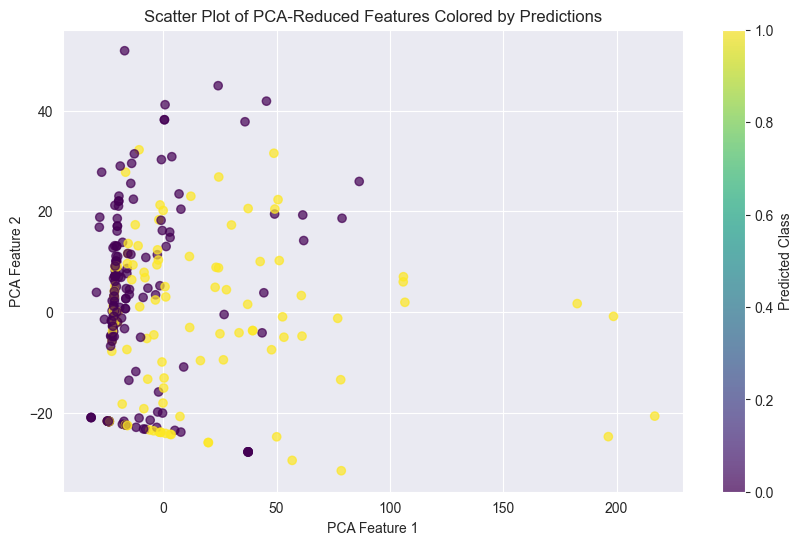

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='viridis', alpha=0.7)
plt.title("Scatter Plot of PCA-Reduced Features Colored by Predictions")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.colorbar(scatter, label="Predicted Class")
plt.show()

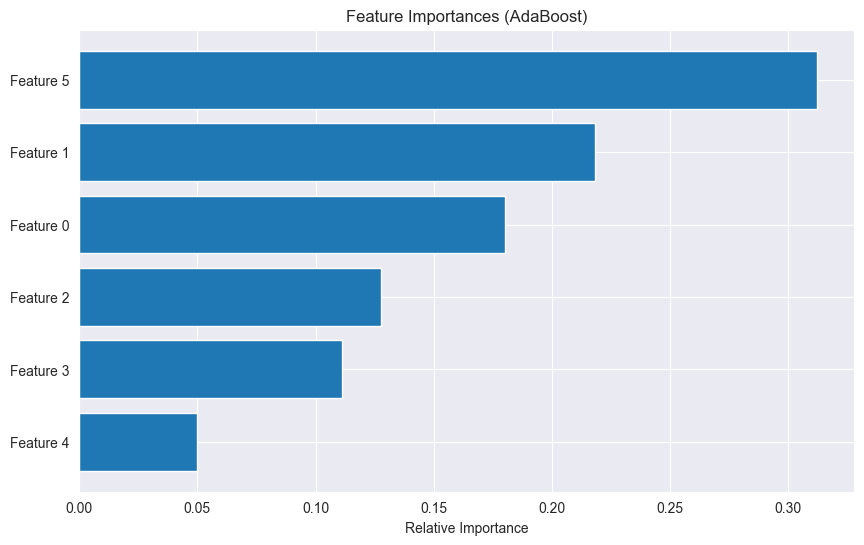

In [27]:
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (AdaBoost)")
plt.barh(range(len(importances)), importances[indices], align="center")
plt.yticks(range(len(importances)), [f"Feature {i}" for i in indices])
plt.xlabel("Relative Importance")
plt.show()


### Concluzie

În această lucrare de laborator, am explorat patru algoritmi de învățare automată pentru clasificare: Naive Bayes, Support Vector Machine (SVM), Arborele de Decizie și AdaBoost. Fiecare algoritm are un principiu de funcționare distinct, adaptat diferitelor tipuri de probleme de clasificare, iar aplicarea acestora pe seturi de date generată ne-a permis să înțelegem cum aceștia abordează problema identificării claselor într-un set de date. Evaluarea performanței algoritmilor folosind măsuri precum precizia, recall-ul, scorul F și matricea de confuzie a oferit o imagine clară asupra eficienței fiecărui model, evidențiind atât avantajele, cât și limitările fiecărei metode.